In [1]:
# !conda install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================
# File paths
# =========================================
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_XY_Final_Fixed.xlsx"
output_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"

# =========================================
# User settings
# Replace with your real coordinate column names
# =========================================
X_COL = "x"
Y_COL = "y"
N_OLD = 150

# =========================================
# Read data
# =========================================
df = pd.read_excel(file_path)

required_cols = ["PLOTWT", "HA", "SHAPE_Area", "Join_Count", X_COL, Y_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================
# Step 1: Compute observed mass-based yield
# =========================================
df["Yield_mass_kg_ha"] = ((df["PLOTWT"] / 1000.0) / df["HA"]) * 10000.0

# Agronomic predictors
df["Area_Ratio"] = df["HA"] / df["SHAPE_Area"]
df["Stand_Ratio"] = df["Join_Count"] / N_OLD

# =========================================
# Step 2: Keep valid rows
# =========================================
valid = (
    df["Yield_mass_kg_ha"].notna() &
    df["Area_Ratio"].notna() &
    df["Stand_Ratio"].notna() &
    df[X_COL].notna() &
    df[Y_COL].notna() &
    np.isfinite(df["Yield_mass_kg_ha"]) &
    np.isfinite(df["Area_Ratio"]) &
    np.isfinite(df["Stand_Ratio"]) &
    np.isfinite(df[X_COL]) &
    np.isfinite(df[Y_COL]) &
    (df["Yield_mass_kg_ha"] > 0) &
    (df["Area_Ratio"] > 0) &
    (df["Stand_Ratio"] > 0)
)

fit_df = df.loc[valid].copy()

if len(fit_df) < 20:
    raise ValueError("Not enough valid rows to fit the spatial residual model reliably.")

# =========================================
# Step 3: Fit agronomic base model on log scale
# log(Y) = b0 + b1*log(Area_Ratio) + b2*log(Stand_Ratio)
# =========================================
fit_df["log_y"] = np.log(fit_df["Yield_mass_kg_ha"])
fit_df["log_area"] = np.log(fit_df["Area_Ratio"])
fit_df["log_stand"] = np.log(fit_df["Stand_Ratio"])

X_base = sm.add_constant(fit_df[["log_area", "log_stand"]])
y_base = fit_df["log_y"]

base_model = sm.OLS(y_base, X_base).fit()
print(base_model.summary())

# Base prediction
fit_df["log_y_base_pred"] = base_model.predict(X_base)
fit_df["base_residual"] = fit_df["log_y"] - fit_df["log_y_base_pred"]

# =========================================
# Step 4: Fit Gaussian Process to spatial residuals
# kriging-style residual surface
# =========================================
coords = fit_df[[X_COL, Y_COL]].values
residuals = fit_df["base_residual"].values

kernel = (
    C(1.0, (1e-3, 1e3)) *
    RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e5)) +
    WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-8, 1e1))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=42
)

gpr.fit(coords, residuals)

print("\nFitted GPR kernel for spatial residuals:")
print(gpr.kernel_)

# =========================================
# Step 5: Predict for all valid rows
# =========================================
df["Yield_BaseModel_kg_ha"] = np.nan
df["Spatial_Residual_Log"] = np.nan
df["Yield_SpatialResidualAdjusted_kg_ha"] = np.nan

pred_df = df.loc[valid].copy()
pred_df["log_area"] = np.log(pred_df["Area_Ratio"])
pred_df["log_stand"] = np.log(pred_df["Stand_Ratio"])

X_base_pred = sm.add_constant(pred_df[["log_area", "log_stand"]], has_constant="add")
log_y_base_pred_all = base_model.predict(X_base_pred)

coords_all = pred_df[[X_COL, Y_COL]].values
spatial_resid_pred, spatial_resid_std = gpr.predict(coords_all, return_std=True)

log_y_spatial_adj = log_y_base_pred_all + spatial_resid_pred
y_spatial_adj = np.exp(log_y_spatial_adj)
y_base_only = np.exp(log_y_base_pred_all)

df.loc[valid, "Yield_BaseModel_kg_ha"] = y_base_only
df.loc[valid, "Spatial_Residual_Log"] = spatial_resid_pred
df.loc[valid, "Yield_SpatialResidualAdjusted_kg_ha"] = y_spatial_adj
df.loc[valid, "Spatial_Residual_SD"] = spatial_resid_std

# =========================================
# Step 6: Diagnostics
# =========================================
eval_df = df.loc[valid].copy()

r2_base = r2_score(eval_df["Yield_mass_kg_ha"], eval_df["Yield_BaseModel_kg_ha"])
rmse_base = np.sqrt(mean_squared_error(eval_df["Yield_mass_kg_ha"], eval_df["Yield_BaseModel_kg_ha"]))
mae_base = mean_absolute_error(eval_df["Yield_mass_kg_ha"], eval_df["Yield_BaseModel_kg_ha"])

r2_sp = r2_score(eval_df["Yield_mass_kg_ha"], eval_df["Yield_SpatialResidualAdjusted_kg_ha"])
rmse_sp = np.sqrt(mean_squared_error(eval_df["Yield_mass_kg_ha"], eval_df["Yield_SpatialResidualAdjusted_kg_ha"]))
mae_sp = mean_absolute_error(eval_df["Yield_mass_kg_ha"], eval_df["Yield_SpatialResidualAdjusted_kg_ha"])

print("\nBase model performance:")
print(f"R2   = {r2_base:.4f}")
print(f"RMSE = {rmse_base:.4f}")
print(f"MAE  = {mae_base:.4f}")

print("\nSpatial residual adjusted model performance:")
print(f"R2   = {r2_sp:.4f}")
print(f"RMSE = {rmse_sp:.4f}")
print(f"MAE  = {mae_sp:.4f}")

# =========================================
# Save output
# =========================================
df.to_excel(output_path, index=False)

print("\nSaved file to:")
print(output_path)

In [ ]:
# !pip install statsmodels

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# =====================================
# File path
# =====================================
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"
output_folder = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Residual_Maps"

# Create output folder
os.makedirs(output_folder, exist_ok=True)

# =====================================
# Column names
# Replace these with your actual column names
# =====================================
X_COL = "x"
Y_COL = "y"
LOCATION_COL = "loc"   # example: "Location"
YEAR_COL = "year"           # example: "Year"
N_OLD = 150

# =====================================
# Load data
# =====================================
df = pd.read_excel(file_path)

# Convert numeric columns
numeric_cols = ["PLOTWT", "HA", "SHAPE_Area", "Join_Count", X_COL, Y_COL]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =====================================
# Compute base yield
# =====================================
df["Yield_mass"] = ((df["PLOTWT"] / 1000) / df["HA"]) * 10000
df["Area_ratio"] = df["HA"] / df["SHAPE_Area"]
df["Stand_ratio"] = df["Join_Count"] / N_OLD

# =====================================
# Keep valid rows
# =====================================
valid = (
    df["Yield_mass"].notna() &
    df["Area_ratio"].notna() &
    df["Stand_ratio"].notna() &
    df[X_COL].notna() &
    df[Y_COL].notna() &
    (df["Yield_mass"] > 0) &
    (df["Area_ratio"] > 0) &
    (df["Stand_ratio"] > 0)
)

df_valid = df.loc[valid].copy()

# =====================================
# Group by location and year
# =====================================
group_cols = [LOCATION_COL, YEAR_COL]

for group_values, group_df in df_valid.groupby(group_cols):
    location_val, year_val = group_values

    # Skip very small groups
    if len(group_df) < 10:
        print(f"Skipping {location_val}, {year_val} because it has fewer than 10 valid rows.")
        continue

    # ---------------------------------
    # Fit agronomic model for this group
    # ---------------------------------
    group_df = group_df.copy()
    group_df["log_y"] = np.log(group_df["Yield_mass"])
    group_df["log_area"] = np.log(group_df["Area_ratio"])
    group_df["log_stand"] = np.log(group_df["Stand_ratio"])

    X = sm.add_constant(group_df[["log_area", "log_stand"]])
    y = group_df["log_y"]

    model = sm.OLS(y, X).fit()

    # Residuals
    group_df["log_pred"] = model.predict(X)
    group_df["residual"] = group_df["log_y"] - group_df["log_pred"]

    # ---------------------------------
    # Plot residual map
    # ---------------------------------
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        group_df[X_COL],
        group_df[Y_COL],
        c=group_df["residual"],
        cmap="RdYlBu_r",
        s=50
    )

    plt.colorbar(scatter, label="Residual (log yield)")
    plt.xlabel("Field X coordinate")
    plt.ylabel("Field Y coordinate")
    plt.title(f"Spatial Residual Map\nLocation: {location_val} | Year: {year_val}")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()

    # Safe filename
    safe_location = str(location_val).replace(" ", "_").replace("/", "_")
    safe_year = str(year_val).replace(" ", "_").replace("/", "_")
    out_png = os.path.join(output_folder, f"ResidualMap_{safe_location}_{safe_year}.png")

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_png}")

print("Done.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# File path
# ==============================
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"

TRIAL_COL = "Experiment Name"
N_OLD = 150

# ==============================
# Load data
# ==============================
df = pd.read_excel(file_path)

# Ensure numeric
df["HA"] = pd.to_numeric(df["HA"], errors="coerce")
df["SHAPE_Area"] = pd.to_numeric(df["SHAPE_Area"], errors="coerce")
df["Join_Count"] = pd.to_numeric(df["Join_Count"], errors="coerce")

# ==============================
# Compute metrics
# ==============================
df["Missing_Area_pct"] = (1 - df["HA"] / df["SHAPE_Area"]) * 100
df["Stand_pct"] = (df["Join_Count"] / N_OLD) * 100

# ==============================
# Trial averages
# ==============================
trial_summary = df.groupby(TRIAL_COL).agg(
    Avg_Missing_Area=("Missing_Area_pct", "mean"),
    Avg_Stand=("Stand_pct", "mean")
).reset_index()

# Sort trials for cleaner plot
trial_summary = trial_summary.sort_values(TRIAL_COL)

# ==============================
# Plot
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---- Missing Area ----
axes[0].bar(
    trial_summary[TRIAL_COL].astype(str),
    trial_summary["Avg_Missing_Area"],
    color="orange"
)

axes[0].set_title("Average Missing Area per Trial")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Missing Area (%)")
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', alpha=0.3)

# ---- Stand ----
axes[1].bar(
    trial_summary[TRIAL_COL].astype(str),
    trial_summary["Avg_Stand"],
    color="steelblue"
)

axes[1].set_title("Average Stand per Trial")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Stand (%)")
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Missing area.png',dpi = 350)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==============================
# 1. FILE PATHS & CONFIG
# ==============================
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"

# Threshold line locations for the first two subplots
MISSING_AREA_HATCH_POS = 40.0  
STAND_HATCH_POS = 32.0         

# ==============================
# 2. LOAD & CLEAN DATA
# ==============================
df = pd.read_excel(file_path)

# Force numeric types and clean PlotID
df["HA"] = pd.to_numeric(df["HA"], errors="coerce")
df["SHAPE_Area"] = pd.to_numeric(df["SHAPE_Area"], errors="coerce")
df["Join_Count"] = pd.to_numeric(df["Join_Count"], errors="coerce")

# Compute metrics
df["Missing_Area_pct"] = (1 - df["HA"] / df["SHAPE_Area"]) * 100
df["Stand_pct"] = (df["Join_Count"] / 150) * 100

# Group by Trial
trial_summary = df.groupby("Experiment Name").agg(
    Avg_Missing_Area=("Missing_Area_pct", "mean"),
    Avg_Stand=("Stand_pct", "mean")
).reset_index()

# ==============================
# 3. MANUAL CV DATA & DELTA CALCULATION
# ==============================
cv_data = [
    {"Experiment Name": "2512",  "CV_Uncorrected": 15.3, "CV_Corrected": 99.4},
    {"Experiment Name": "25114", "CV_Uncorrected": 12.4, "CV_Corrected": 7.7},
    {"Experiment Name": "25113", "CV_Uncorrected": 27.3, "CV_Corrected": 12.3},
    {"Experiment Name": "25112", "CV_Uncorrected": 22.5, "CV_Corrected": 22.6},
    {"Experiment Name": "25111", "CV_Uncorrected": 26.2, "CV_Corrected": 12.9},
    {"Experiment Name": "25106", "CV_Uncorrected": 26.8, "CV_Corrected": 19.3},
    {"Experiment Name": "25105", "CV_Uncorrected": 34.5, "CV_Corrected": 9.6},
    {"Experiment Name": "25104", "CV_Uncorrected": 34.8, "CV_Corrected": 14.6},
    {"Experiment Name": "2508",  "CV_Uncorrected": 8.6,  "CV_Corrected": 22.6},
    {"Experiment Name": "2507",  "CV_Uncorrected": 6.6,  "CV_Corrected": 16.8},
    {"Experiment Name": "2506",  "CV_Uncorrected":0,  "CV_Corrected": 0},
    {"Experiment Name": "2505",  "CV_Uncorrected": 8.9,  "CV_Corrected": 15.6},
    {"Experiment Name": "2504",  "CV_Uncorrected": 6.7,  "CV_Corrected": 52.9},
    {"Experiment Name": "2503",  "CV_Uncorrected": 7.4,  "CV_Corrected": 54.9},
    {"Experiment Name": "2502",  "CV_Uncorrected": 10.3, "CV_Corrected": 50.4},
    {"Experiment Name": "2412", "CV_Uncorrected": 7.11, "CV_Corrected": 1.8},
    {"Experiment Name": "24116", "CV_Uncorrected": 23.2, "CV_Corrected": 20.8},
    {"Experiment Name": "2411", "CV_Uncorrected": 7.0, "CV_Corrected": 3.3},
    {"Experiment Name": "2410", "CV_Uncorrected": 7.8, "CV_Corrected": 2.5},
    {"Experiment Name": "2409", "CV_Uncorrected": 0, "CV_Corrected": 0},
    {"Experiment Name": "2408",  "CV_Uncorrected": 0,  "CV_Corrected": 0},
    {"Experiment Name": "2407",  "CV_Uncorrected": 7.9,  "CV_Corrected": 2.9},
    {"Experiment Name": "2406",  "CV_Uncorrected": 8.8,  "CV_Corrected": 4.6},
    {"Experiment Name": "2405",  "CV_Uncorrected": 8.3,  "CV_Corrected": 2.7},
    {"Experiment Name": "2404",  "CV_Uncorrected":9.6,  "CV_Corrected": 3.8},
    {"Experiment Name": "2403",  "CV_Uncorrected": 9.5, "CV_Corrected": 4.4},
    {"Experiment Name": "2402",  "CV_Uncorrected": 9.1,  "CV_Corrected": 4.3},
    {"Experiment Name": "2219",  "CV_Uncorrected": 12.11, "CV_Corrected": 0.7},
    {"Experiment Name": "2218",  "CV_Uncorrected": 13.4, "CV_Corrected": 2.1},
    {"Experiment Name": "2217",  "CV_Uncorrected": 16.6, "CV_Corrected": 4.4},
    {"Experiment Name": "2202",  "CV_Uncorrected": 9.8,  "CV_Corrected": 6.4},
    {"Experiment Name": "2201",  "CV_Uncorrected": 10.4, "CV_Corrected": 5.7},
    {"Experiment Name": "2116",  "CV_Uncorrected": 9.5, "CV_Corrected": 33.5},
    {"Experiment Name": "2115",  "CV_Uncorrected": 10.7, "CV_Corrected": 27.5},

]

cv_df = pd.DataFrame(cv_data)

# Calculate Delta: (Corrected - Uncorrected)
# If negative = Improvement (reduction in error)
# If positive = Worsening (increase in error)
cv_df["CV_Delta"] = cv_df["CV_Corrected"] - cv_df["CV_Uncorrected"]

def clean_id(val):
    digits = re.findall(r'\d+', str(val))
    return "".join(digits) if digits else ""

trial_summary["Match_ID"] = trial_summary["Experiment Name"].apply(clean_id)
cv_df["Match_ID"] = cv_df["Experiment Name"].apply(clean_id)

final_summary = trial_summary.merge(cv_df.drop(columns="Experiment Name"), on="Match_ID", how="left")
final_summary = final_summary.sort_values("Match_ID").reset_index(drop=True)
labels = final_summary["Experiment Name"].astype(str)

# ==============================
# 4. VISUALIZATION
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(44, 20), sharey=True)
plt.subplots_adjust(wspace=0.34)

# Define standard sizes
TITLE_SIZE = 45
LABEL_SIZE = 42
TICK_SIZE = 42

delta_colors = ['#2ca02c' if x < 0 else '#d62728' for x in final_summary["CV_Delta"]]

# Plot 1
axes[0].barh(labels, final_summary["Avg_Missing_Area"], color="#FFA500", alpha=0.7)
axes[0].axvline(x=MISSING_AREA_HATCH_POS, color='black', linestyle='--', linewidth=4.6)
axes[0].set_title("Avg Missing Area (%)", fontsize=TITLE_SIZE, weight="bold")
axes[0].set_xlabel("Mean Area Missing", fontsize=TICK_SIZE)

# Plot 2
axes[1].barh(labels, final_summary["Avg_Stand"], color="#4682B4", alpha=0.7)
axes[1].axvline(x=STAND_HATCH_POS, color='black', linestyle='--', linewidth=4.6)
axes[1].set_title("Avg Stand Count (%)", fontsize=TITLE_SIZE, weight="bold")
axes[1].set_xlabel("Mean Stand % of Target", fontsize=TICK_SIZE)

# Plot 3
axes[2].barh(labels, final_summary["CV_Delta"], color=delta_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].axvline(x=0, color='black', linewidth=4.6)
axes[2].set_title("CV Impact ($\Delta$ CV)", fontsize=TITLE_SIZE, weight="bold")
axes[2].set_xlabel("Reduction (-) vs. Increase (+) in CV", fontsize=TICK_SIZE)

# FORCE CONSISTENT FONT SIZES ACROSS ALL SUBPLOTS
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    # Ensure the Y-axis labels (Trial IDs) are visible and sized correctly on the first plot
    ax.yaxis.get_label().set_fontsize(TICK_SIZE)

# Annotations (using the defined TICK_SIZE for consistency)
for i, v in enumerate(final_summary["CV_Delta"]):
    if pd.notna(v):
        ha = 'right' if v < 0 else 'left'
        offset = -0.5 if v < 0 else 0.5
        axes[2].text(v + offset, i, f"{v:+.1f}", va="center", ha=ha, 
                     color='black', fontweight='bold', fontsize=32)

for i in range(len(final_summary)):
    m = final_summary.loc[i, "Avg_Missing_Area"]
    if pd.notna(m): axes[0].text(m + 0.5, i, f"{m:.1f}", va="center", fontsize=32, fontweight='bold')
    s = final_summary.loc[i, "Avg_Stand"]
    if pd.notna(s): axes[1].text(s + 0.5, i, f"{s:.1f}", va="center", fontsize=32, fontweight='bold')

axes[0].invert_yaxis()
plt.tight_layout()
plt.savefig('Three_Panel_Plot_Uniform.png', dpi=350)
plt.show()

In [ ]:
#sensitiveity analaysis

In [ ]:
# !pip install sklearn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.utils import resample
import statsmodels.api as sm

# ==============================
# 1. SEGMENTED REGRESSION FUNCTION
# ==============================
def fit_segmented(x, y, initial_breakpoint):
    """Fits a piecewise linear model to find a breakpoint."""
    def piecewise_linear(x, x0, y0, k1, k2):
        return np.piecewise(x, [x < x0], [lambda x: k1*x + y0 - k1*x0, lambda x: k2*x + y0 - k2*x0])
    
    from scipy.optimize import curve_fit
    p, e = curve_fit(piecewise_linear, x, y, p0=[initial_breakpoint, np.mean(y), 0, 1])
    return p, e

# ==============================
# 2. BOOTSTRAPPING FOR BREAKPOINT CI
# ==============================
def bootstrap_breakpoint(df, x_col, y_col, n_iterations=1000):
    breakpoints = []
    for _ in range(n_iterations):
        sample = resample(df)
        try:
            p, _ = fit_segmented(sample[x_col], sample[y_col], sample[x_col].median())
            breakpoints.append(p[0])
        except:
            continue
    return np.percentile(breakpoints, [2.5, 97.5])

# ==============================
# 3. THRESHOLD VALIDATION TABLE
# ==============================
def generate_validation_table(df):
    bins = [0, 20, 40, 60, 100]
    labels = ['0-20%', '20-40%', '40-60%', '>60%']
    df['Bin'] = pd.cut(df['Avg_Missing_Area'], bins=bins, labels=labels)
    
    summary = df.groupby('Bin').agg(
        n_plots=('Match_ID', 'count'),
        mean_DeltaCV=('CV_Delta', 'mean'),
        Improved_Trials_Pct=('CV_Delta', lambda x: (x < 0).mean() * 100)
    ).reset_index()
    return summary

# ==============================
# 4. LOCATION-SPECIFIC ANALYSIS
# ==============================
# Example stratification by location (assuming Location column exists)
def check_environment_specificity(df):
    locations = df['Location'].unique()
    results = {}
    for loc in locations:
        loc_df = df[df['Location'] == loc]
        p, _ = fit_segmented(loc_df['Avg_Missing_Area'], loc_df['CV_Delta'], 40)
        results[loc] = p[0]
    return results

# ==============================
# 5. DAVIES TEST (LINEARITY VS SEGMENTED)
# ==============================
# Approximated by comparing residuals of linear vs piecewise model
def pseudo_davies_test(x, y, p_piecewise):
    # Null Hypothesis: Linear model is sufficient
    slope, intercept, r_val, p_linear, std_err = stats.linregress(x, y)
    # Return p-value of linear fit to check if non-linearity is significant
    return p_linear

# EXECUTION LOGIC
# 1. Load your final_summary from previous steps
# 2. Run bootstrap_breakpoint(final_summary, "Avg_Missing_Area", "CV_Delta")
# 3. Generate and print the validation table

Per-trial dataset: n = 34 trials

Fitting segmented regressions ...


C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1013874606.py:129: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)


  [Missing area (%)]  BP = 39.06%
           Wald      CI = [10.69, 67.42]  (±28.36)
           Bootstrap CI = [25.48, 57.59]  (n_ok = 1000/1000)
           k1 = 0.391   k2 = 1.357   pseudo-Davies p = <0.001

  [Stand count (%)]  BP = 37.63%
           Wald      CI = [22.51, 52.76]  (±15.13)
           Bootstrap CI = [-62.42, 78.16]  (n_ok = 1000/1000)
           k1 = -1.350   k2 = -0.078   pseudo-Davies p = 0.002

Table 6:
                          model  breakpoint  wald_lo  wald_hi  wald_hw  boot_lo  boot_hi  pseudo_davies_p  k_left  k_right  n_trials  boot_n_ok
Delta_CV ~ Avg_Missing_Area (%)      39.057   10.694   67.421   28.363    25.48   57.593            0.000   0.391    1.357        34       1000
       Delta_CV ~ Avg_Stand (%)      37.635   22.505   52.764   15.130   -62.42   78.157            0.002  -1.350   -0.078        34       1000

Wrote C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python/figS8_segmented_python.png
Wrote C:\Users\bazrafka\Desktop\counting\Dis

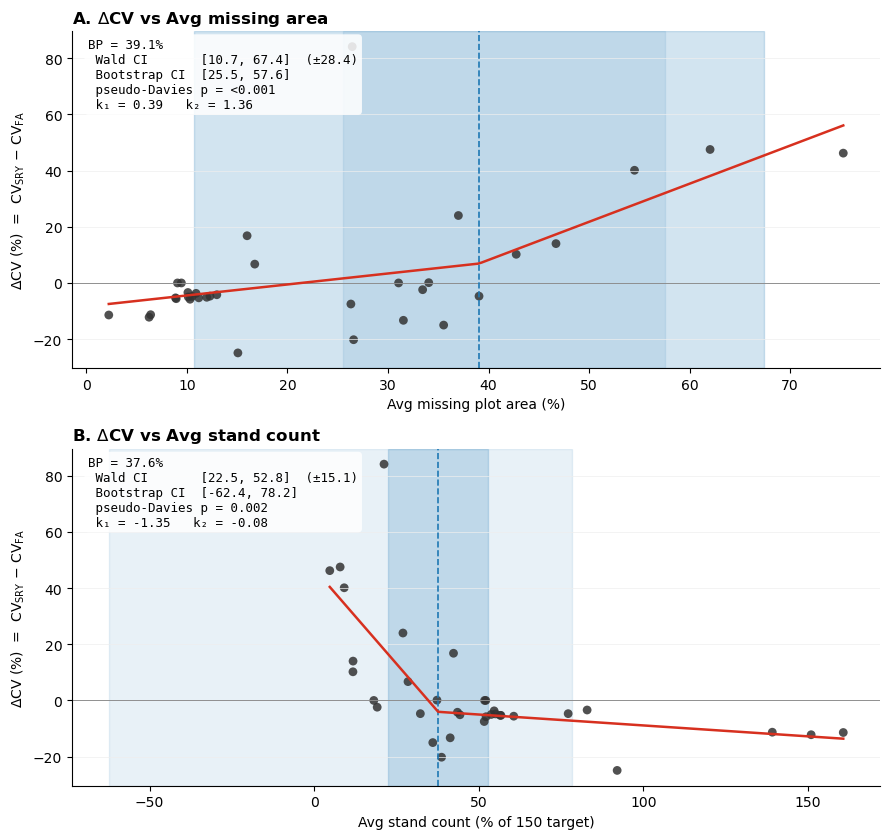

In [4]:
"""
Segmented-regression figure for Section 3.6.1.

Reads:
  - Ali_Data_with_spatial_residual_adjusted_yield.xlsx  (for HA, SHAPE_Area, Join_Count, loc)
  - Hand-typed cv_data list below (CV_FA and CV_SRY per trial)

Outputs:
  - figS8_segmented_python.png       two-panel broken-stick figure
  - table6_segmented_python.csv      breakpoint, Wald CI, bootstrap CI, slopes
  - per_trial_data_python.csv        the n=34 per-trial dataset that was fit
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.utils import resample

# ============================================================================
# CONFIG
# ============================================================================
FILE_PATH       = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"
OUT_DIR         = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python"
N_BOOT          = 1000
INIT_BP_MISSING = 40
INIT_BP_STAND   = 32
RANDOM_SEED     = 42

np.random.seed(RANDOM_SEED)

# ============================================================================
# HAND-TYPED CV TABLE (column names renamed to FA / SRY per manuscript)
# ============================================================================
cv_data = [
    {"Experiment Name": "2512",  "CV_FA": 15.3, "CV_SRY": 99.4},
    {"Experiment Name": "25114", "CV_FA": 12.4, "CV_SRY":  7.7},
    {"Experiment Name": "25113", "CV_FA": 27.3, "CV_SRY": 12.3},
    {"Experiment Name": "25112", "CV_FA": 22.5, "CV_SRY": 22.6},
    {"Experiment Name": "25111", "CV_FA": 26.2, "CV_SRY": 12.9},
    {"Experiment Name": "25106", "CV_FA": 26.8, "CV_SRY": 19.3},
    {"Experiment Name": "25105", "CV_FA": 34.5, "CV_SRY":  9.6},
    {"Experiment Name": "25104", "CV_FA": 34.8, "CV_SRY": 14.6},
    {"Experiment Name": "2508",  "CV_FA":  8.6, "CV_SRY": 22.6},
    {"Experiment Name": "2507",  "CV_FA":  6.6, "CV_SRY": 16.8},
    {"Experiment Name": "2506",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2505",  "CV_FA":  8.9, "CV_SRY": 15.6},
    {"Experiment Name": "2504",  "CV_FA":  6.7, "CV_SRY": 52.9},
    {"Experiment Name": "2503",  "CV_FA":  7.4, "CV_SRY": 54.9},
    {"Experiment Name": "2502",  "CV_FA": 10.3, "CV_SRY": 50.4},
    {"Experiment Name": "2412",  "CV_FA":  7.11,"CV_SRY":  1.8},
    {"Experiment Name": "24116", "CV_FA": 23.2, "CV_SRY": 20.8},
    {"Experiment Name": "2411",  "CV_FA":  7.0, "CV_SRY":  3.3},
    {"Experiment Name": "2410",  "CV_FA":  7.8, "CV_SRY":  2.5},
    {"Experiment Name": "2409",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2408",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2407",  "CV_FA":  7.9, "CV_SRY":  2.9},
    {"Experiment Name": "2406",  "CV_FA":  8.8, "CV_SRY":  4.6},
    {"Experiment Name": "2405",  "CV_FA":  8.3, "CV_SRY":  2.7},
    {"Experiment Name": "2404",  "CV_FA":  9.6, "CV_SRY":  3.8},
    {"Experiment Name": "2403",  "CV_FA":  9.5, "CV_SRY":  4.4},
    {"Experiment Name": "2402",  "CV_FA":  9.1, "CV_SRY":  4.3},
    {"Experiment Name": "2219",  "CV_FA": 12.11,"CV_SRY":  0.7},
    {"Experiment Name": "2218",  "CV_FA": 13.4, "CV_SRY":  2.1},
    {"Experiment Name": "2217",  "CV_FA": 16.6, "CV_SRY":  4.4},
    {"Experiment Name": "2202",  "CV_FA":  9.8, "CV_SRY":  6.4},
    {"Experiment Name": "2201",  "CV_FA": 10.4, "CV_SRY":  5.7},
    {"Experiment Name": "2116",  "CV_FA":  9.5, "CV_SRY": 33.5},
    {"Experiment Name": "2115",  "CV_FA": 10.7, "CV_SRY": 27.5},
]
cv_df = pd.DataFrame(cv_data)
cv_df["CV_Delta"] = cv_df["CV_SRY"] - cv_df["CV_FA"]


# ============================================================================
# LOAD XLSX, BUILD PER-TRIAL TABLE
# ============================================================================
df = pd.read_excel(FILE_PATH)
df["HA"]         = pd.to_numeric(df["HA"], errors="coerce")
df["SHAPE_Area"] = pd.to_numeric(df["SHAPE_Area"], errors="coerce")
df["Join_Count"] = pd.to_numeric(df["Join_Count"], errors="coerce")
df["Missing_Area_pct"] = (1 - df["HA"] / df["SHAPE_Area"]) * 100
df["Stand_pct"]        = (df["Join_Count"] / 150) * 100

trial_summary = (df.groupby("Experiment Name")
                   .agg(Avg_Missing_Area=("Missing_Area_pct", "mean"),
                        Avg_Stand=("Stand_pct", "mean"))
                   .reset_index())


def clean_id(val):
    digits = re.findall(r"\d+", str(val))
    return "".join(digits) if digits else ""


trial_summary["Match_ID"] = trial_summary["Experiment Name"].apply(clean_id)
cv_df["Match_ID"]         = cv_df["Experiment Name"].apply(clean_id)

final_summary = (trial_summary
                 .merge(cv_df.drop(columns="Experiment Name"),
                        on="Match_ID", how="left")
                 .dropna(subset=["CV_Delta"])
                 .sort_values("Match_ID")
                 .reset_index(drop=True))

final_summary.to_csv(f"{OUT_DIR}/per_trial_data_python.csv", index=False)
print(f"Per-trial dataset: n = {len(final_summary)} trials\n")


# ============================================================================
# SEGMENTED REGRESSION FUNCTIONS
# ============================================================================
def piecewise_linear(x, x0, y0, k1, k2):
    """Continuous piecewise-linear with breakpoint at x0."""
    return np.piecewise(
        x,
        [x < x0],
        [lambda x: k1 * x + y0 - k1 * x0,
         lambda x: k2 * x + y0 - k2 * x0],
    )


def fit_segmented(x, y, initial_bp):
    """Returns (params, param_stderr) or (None, None) if the fit fails."""
    try:
        p0   = [initial_bp, np.mean(y), 0, 1]
        p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
        se   = np.sqrt(np.diag(cov))
        return p, se
    except Exception:
        return None, None


def bootstrap_bp(df, x_col, y_col, initial_bp, n_iter=N_BOOT):
    """Percentile bootstrap CI for the breakpoint."""
    bps = []
    for _ in range(n_iter):
        sample = resample(df)
        p, _ = fit_segmented(sample[x_col].values,
                             sample[y_col].values,
                             initial_bp)
        if p is not None:
            bps.append(p[0])
    if len(bps) < 50:
        return np.array([np.nan, np.nan]), len(bps)
    return np.percentile(bps, [2.5, 97.5]), len(bps)


def pseudo_davies(x, y):
    """Linear-fit p-value (matches original Python `pseudo_davies_test`)."""
    return stats.linregress(x, y).pvalue


# ============================================================================
# RUN FITS
# ============================================================================
def run_one(predictor, label, initial_bp):
    x = final_summary[predictor].values
    y = final_summary["CV_Delta"].values
    p, se = fit_segmented(x, y, initial_bp)
    if p is None:
        print(f"  [{label}] fit failed.")
        return None
    x0, y0, k1, k2 = p
    se_x0 = se[0]
    wald_hw = 1.96 * se_x0
    boot_ci, n_ok = bootstrap_bp(final_summary, predictor, "CV_Delta",
                                 initial_bp)
    p_dav = pseudo_davies(x, y)

    print(f"  [{label}]  BP = {x0:.2f}%")
    print(f"           Wald      CI = [{x0 - wald_hw:.2f}, {x0 + wald_hw:.2f}]"
          f"  (±{wald_hw:.2f})")
    print(f"           Bootstrap CI = [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]"
          f"  (n_ok = {n_ok}/{N_BOOT})")
    print(f"           k1 = {k1:.3f}   k2 = {k2:.3f}   pseudo-Davies p = "
          f"{'<0.001' if p_dav < 0.001 else f'{p_dav:.3f}'}\n")

    return {
        "predictor": predictor, "label": label,
        "x0": x0, "y0": y0, "k1": k1, "k2": k2,
        "wald_lo": x0 - wald_hw, "wald_hi": x0 + wald_hw, "wald_hw": wald_hw,
        "boot_lo": boot_ci[0], "boot_hi": boot_ci[1], "boot_n_ok": n_ok,
        "p_dav": p_dav,
    }


print("Fitting segmented regressions ...")
res_miss  = run_one("Avg_Missing_Area", "Missing area (%)", INIT_BP_MISSING)
res_stand = run_one("Avg_Stand",        "Stand count (%)",  INIT_BP_STAND)


# ============================================================================
# TABLE 6
# ============================================================================
table6 = pd.DataFrame([
    {
        "model": "Delta_CV ~ Avg_Missing_Area (%)",
        "breakpoint": res_miss["x0"]  if res_miss  else np.nan,
        "wald_lo":    res_miss["wald_lo"] if res_miss else np.nan,
        "wald_hi":    res_miss["wald_hi"] if res_miss else np.nan,
        "wald_hw":    res_miss["wald_hw"] if res_miss else np.nan,
        "boot_lo":    res_miss["boot_lo"] if res_miss else np.nan,
        "boot_hi":    res_miss["boot_hi"] if res_miss else np.nan,
        "pseudo_davies_p": res_miss["p_dav"] if res_miss else np.nan,
        "k_left":     res_miss["k1"] if res_miss else np.nan,
        "k_right":    res_miss["k2"] if res_miss else np.nan,
        "n_trials":   len(final_summary),
        "boot_n_ok":  res_miss["boot_n_ok"] if res_miss else np.nan,
    },
    {
        "model": "Delta_CV ~ Avg_Stand (%)",
        "breakpoint": res_stand["x0"]  if res_stand  else np.nan,
        "wald_lo":    res_stand["wald_lo"] if res_stand else np.nan,
        "wald_hi":    res_stand["wald_hi"] if res_stand else np.nan,
        "wald_hw":    res_stand["wald_hw"] if res_stand else np.nan,
        "boot_lo":    res_stand["boot_lo"] if res_stand else np.nan,
        "boot_hi":    res_stand["boot_hi"] if res_stand else np.nan,
        "pseudo_davies_p": res_stand["p_dav"] if res_stand else np.nan,
        "k_left":     res_stand["k1"] if res_stand else np.nan,
        "k_right":    res_stand["k2"] if res_stand else np.nan,
        "n_trials":   len(final_summary),
        "boot_n_ok":  res_stand["boot_n_ok"] if res_stand else np.nan,
    },
]).round(3)

print("Table 6:")
print(table6.to_string(index=False))
table6.to_csv(f"{OUT_DIR}/table6_segmented_python.csv", index=False)


# ============================================================================
# FIGURE
# ============================================================================
def panel(ax, df, xcol, res, xlabel, title):
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.scatter(df[xcol], df["CV_Delta"],
               s=40, color="#333333", alpha=0.85, edgecolor="none")

    if res is None:
        ax.set_xlabel(xlabel); ax.set_title(title, loc="left", weight="bold")
        return

    # Bootstrap CI (lighter, wider band)
    if np.isfinite(res["boot_lo"]) and np.isfinite(res["boot_hi"]):
        ax.axvspan(res["boot_lo"], res["boot_hi"],
                   alpha=0.10, color="#1f78b4", zorder=0)
    # Wald CI (slightly darker, inner band)
    if np.isfinite(res["wald_lo"]) and np.isfinite(res["wald_hi"]):
        ax.axvspan(res["wald_lo"], res["wald_hi"],
                   alpha=0.20, color="#1f78b4", zorder=0)
    # Breakpoint marker
    ax.axvline(res["x0"], color="#1f78b4",
               linestyle="--", linewidth=1.2)

    # Fitted broken-stick line
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ys = piecewise_linear(xs, res["x0"], res["y0"], res["k1"], res["k2"])
    ax.plot(xs, ys, color="#d7301f", linewidth=1.8)

    # Annotation
    p_text = "<0.001" if res["p_dav"] < 0.001 else f"{res['p_dav']:.3f}"
    label = (f"BP = {res['x0']:.1f}%\n"
             f" Wald CI       [{res['wald_lo']:.1f}, {res['wald_hi']:.1f}]"
             f"  (±{res['wald_hw']:.1f})\n"
             f" Bootstrap CI  [{res['boot_lo']:.1f}, {res['boot_hi']:.1f}]\n"
             f" pseudo-Davies p = {p_text}\n"
             f" k\u2081 = {res['k1']:.2f}   k\u2082 = {res['k2']:.2f}")
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=9, family="monospace",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85,
                      boxstyle="round,pad=0.3"))
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", weight="bold")


fig, axes = plt.subplots(2, 1, figsize=(9, 8.5))
plt.subplots_adjust(hspace=0.35)

# Shared y-axis label
y_lab = r"$\Delta$CV (%)  =  CV$_{\mathrm{SRY}}$ $-$ CV$_{\mathrm{FA}}$"

panel(axes[0], final_summary, "Avg_Missing_Area", res_miss,
      "Avg missing plot area (%)",
      "A. $\\Delta$CV vs Avg missing area")
panel(axes[1], final_summary, "Avg_Stand",        res_stand,
      "Avg stand count (% of 150 target)",
      "B. $\\Delta$CV vs Avg stand count")

for ax in axes:
    ax.set_ylabel(y_lab)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.5)

plt.tight_layout()
out_png = f"{OUT_DIR}/figS8_segmented_python.png"
plt.savefig(out_png, dpi=400, bbox_inches="tight")
print(f"\nWrote {out_png}")
print(f"Wrote {OUT_DIR}/table6_segmented_python.csv")
print(f"Wrote {OUT_DIR}/per_trial_data_python.csv")

In [5]:
# !pip show numpy

In [ ]:
# !pip uninstall numpy

In [2]:
import numpy
print(numpy.__version__)
print(numpy.__file__)

1.26.4
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\numpy\__init__.py


Per-trial dataset: n = 34 trials

Fitting segmented regressions ...


C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)


  [Missing area (%)]  BP = 39.06%
           Wald      CI = [10.69, 67.42]  (±28.36)
           Bootstrap CI = [25.48, 57.59]  (n_ok = 1000/1000)
           k1 = 0.391   k2 = 1.357   pseudo-Davies p = <0.001

  [Stand count (%)]  BP = 37.63%
           Wald      CI = [22.51, 52.76]  (±15.13)
           Bootstrap CI = [-62.42, 78.16]  (n_ok = 1000/1000)
           k1 = -1.350   k2 = -0.078   pseudo-Davies p = 0.002

Table 6:
                          model  breakpoint  wald_lo  wald_hi  wald_hw  boot_lo  boot_hi  pseudo_davies_p  k_left  k_right  n_trials  boot_n_ok
Delta_CV ~ Avg_Missing_Area (%)      39.057   10.694   67.421   28.363    25.48   57.593            0.000   0.391    1.357        34       1000
       Delta_CV ~ Avg_Stand (%)      37.635   22.505   52.764   15.130   -62.42   78.157            0.002  -1.350   -0.078        34       1000

Leave-one-trial-out cross-validation ...
  Classified correctly: 28 / 34 trials (82.4%)
  Mean BP_missing across LOO refits: 38.23%  (SD 2.

C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
C:\Users\bazrafka\AppData\Local\Temp\ipykernel_14016\1732076032.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(piecewise_line

  P(across-location var >= observed) for missing: 0.027
  P(across-location var >= observed) for stand:   0.292

Wrote C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python/figS8_segmented_python.png
Wrote C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python/table6_segmented_python.csv
Wrote C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python/per_trial_data_python.csv


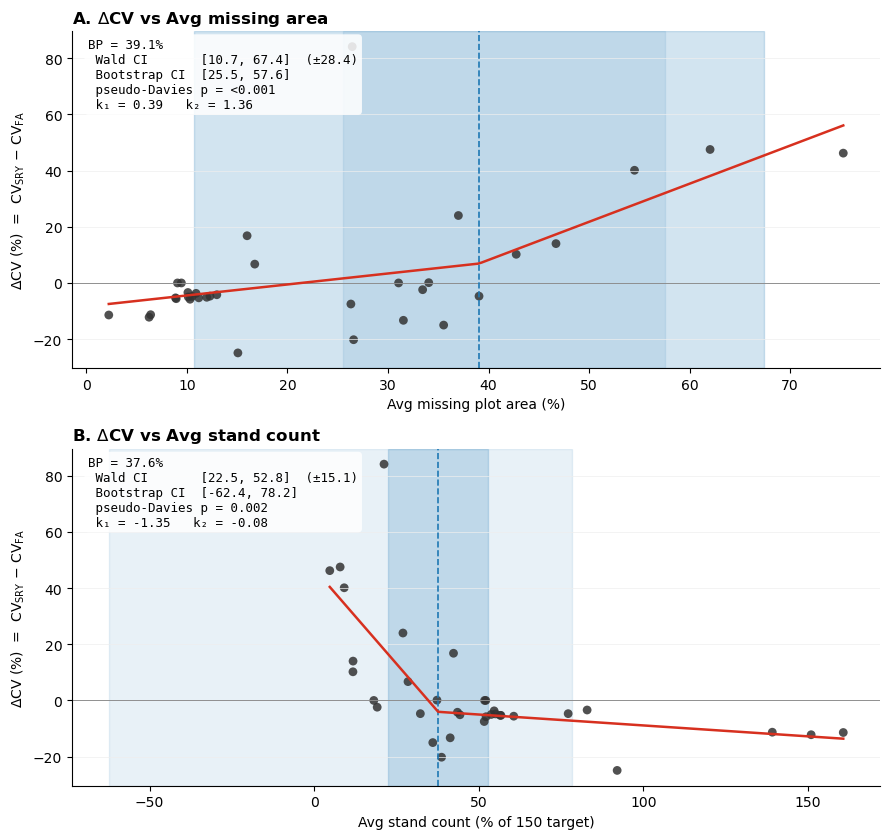

In [6]:
"""
Segmented-regression figure for Section 3.6.1.

Reads:
  - Ali_Data_with_spatial_residual_adjusted_yield.xlsx  (for HA, SHAPE_Area, Join_Count, loc)
  - Hand-typed cv_data list below (CV_FA and CV_SRY per trial)

Outputs:
  - figS8_segmented_python.png       two-panel broken-stick figure
  - table6_segmented_python.csv      breakpoint, Wald CI, bootstrap CI, slopes
  - per_trial_data_python.csv        the n=34 per-trial dataset that was fit
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.utils import resample

# ============================================================================
# CONFIG
# ============================================================================
FILE_PATH       = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"
OUT_DIR         = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python"
N_BOOT          = 1000
INIT_BP_MISSING = 40
INIT_BP_STAND   = 32
RANDOM_SEED     = 42

np.random.seed(RANDOM_SEED)

# ============================================================================
# HAND-TYPED CV TABLE (column names renamed to FA / SRY per manuscript)
# ============================================================================
cv_data = [
    {"Experiment Name": "2512",  "CV_FA": 15.3, "CV_SRY": 99.4},
    {"Experiment Name": "25114", "CV_FA": 12.4, "CV_SRY":  7.7},
    {"Experiment Name": "25113", "CV_FA": 27.3, "CV_SRY": 12.3},
    {"Experiment Name": "25112", "CV_FA": 22.5, "CV_SRY": 22.6},
    {"Experiment Name": "25111", "CV_FA": 26.2, "CV_SRY": 12.9},
    {"Experiment Name": "25106", "CV_FA": 26.8, "CV_SRY": 19.3},
    {"Experiment Name": "25105", "CV_FA": 34.5, "CV_SRY":  9.6},
    {"Experiment Name": "25104", "CV_FA": 34.8, "CV_SRY": 14.6},
    {"Experiment Name": "2508",  "CV_FA":  8.6, "CV_SRY": 22.6},
    {"Experiment Name": "2507",  "CV_FA":  6.6, "CV_SRY": 16.8},
    {"Experiment Name": "2506",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2505",  "CV_FA":  8.9, "CV_SRY": 15.6},
    {"Experiment Name": "2504",  "CV_FA":  6.7, "CV_SRY": 52.9},
    {"Experiment Name": "2503",  "CV_FA":  7.4, "CV_SRY": 54.9},
    {"Experiment Name": "2502",  "CV_FA": 10.3, "CV_SRY": 50.4},
    {"Experiment Name": "2412",  "CV_FA":  7.11,"CV_SRY":  1.8},
    {"Experiment Name": "24116", "CV_FA": 23.2, "CV_SRY": 20.8},
    {"Experiment Name": "2411",  "CV_FA":  7.0, "CV_SRY":  3.3},
    {"Experiment Name": "2410",  "CV_FA":  7.8, "CV_SRY":  2.5},
    {"Experiment Name": "2409",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2408",  "CV_FA":  0,   "CV_SRY":  0},
    {"Experiment Name": "2407",  "CV_FA":  7.9, "CV_SRY":  2.9},
    {"Experiment Name": "2406",  "CV_FA":  8.8, "CV_SRY":  4.6},
    {"Experiment Name": "2405",  "CV_FA":  8.3, "CV_SRY":  2.7},
    {"Experiment Name": "2404",  "CV_FA":  9.6, "CV_SRY":  3.8},
    {"Experiment Name": "2403",  "CV_FA":  9.5, "CV_SRY":  4.4},
    {"Experiment Name": "2402",  "CV_FA":  9.1, "CV_SRY":  4.3},
    {"Experiment Name": "2219",  "CV_FA": 12.11,"CV_SRY":  0.7},
    {"Experiment Name": "2218",  "CV_FA": 13.4, "CV_SRY":  2.1},
    {"Experiment Name": "2217",  "CV_FA": 16.6, "CV_SRY":  4.4},
    {"Experiment Name": "2202",  "CV_FA":  9.8, "CV_SRY":  6.4},
    {"Experiment Name": "2201",  "CV_FA": 10.4, "CV_SRY":  5.7},
    {"Experiment Name": "2116",  "CV_FA":  9.5, "CV_SRY": 33.5},
    {"Experiment Name": "2115",  "CV_FA": 10.7, "CV_SRY": 27.5},
]
cv_df = pd.DataFrame(cv_data)
cv_df["CV_Delta"] = cv_df["CV_SRY"] - cv_df["CV_FA"]


# ============================================================================
# LOAD XLSX, BUILD PER-TRIAL TABLE
# ============================================================================
df = pd.read_excel(FILE_PATH)
df["HA"]         = pd.to_numeric(df["HA"], errors="coerce")
df["SHAPE_Area"] = pd.to_numeric(df["SHAPE_Area"], errors="coerce")
df["Join_Count"] = pd.to_numeric(df["Join_Count"], errors="coerce")
df["Missing_Area_pct"] = (1 - df["HA"] / df["SHAPE_Area"]) * 100
df["Stand_pct"]        = (df["Join_Count"] / 150) * 100

trial_summary = (df.groupby("Experiment Name")
                   .agg(Avg_Missing_Area=("Missing_Area_pct", "mean"),
                        Avg_Stand=("Stand_pct", "mean"),
                        loc=("loc", "first"))
                   .reset_index())


def clean_id(val):
    digits = re.findall(r"\d+", str(val))
    return "".join(digits) if digits else ""


trial_summary["Match_ID"] = trial_summary["Experiment Name"].apply(clean_id)
cv_df["Match_ID"]         = cv_df["Experiment Name"].apply(clean_id)

final_summary = (trial_summary
                 .merge(cv_df.drop(columns="Experiment Name"),
                        on="Match_ID", how="left")
                 .dropna(subset=["CV_Delta"])
                 .sort_values("Match_ID")
                 .reset_index(drop=True))

final_summary.to_csv(f"{OUT_DIR}/per_trial_data_python.csv", index=False)
print(f"Per-trial dataset: n = {len(final_summary)} trials\n")


# ============================================================================
# SEGMENTED REGRESSION FUNCTIONS
# ============================================================================
def piecewise_linear(x, x0, y0, k1, k2):
    """Continuous piecewise-linear with breakpoint at x0."""
    return np.piecewise(
        x,
        [x < x0],
        [lambda x: k1 * x + y0 - k1 * x0,
         lambda x: k2 * x + y0 - k2 * x0],
    )


def fit_segmented(x, y, initial_bp):
    """Returns (params, param_stderr) or (None, None) if the fit fails."""
    try:
        p0   = [initial_bp, np.mean(y), 0, 1]
        p, cov = curve_fit(piecewise_linear, x, y, p0=p0, maxfev=5000)
        se   = np.sqrt(np.diag(cov))
        return p, se
    except Exception:
        return None, None


def bootstrap_bp(df, x_col, y_col, initial_bp, n_iter=N_BOOT):
    """Percentile bootstrap CI for the breakpoint."""
    bps = []
    for _ in range(n_iter):
        sample = resample(df)
        p, _ = fit_segmented(sample[x_col].values,
                             sample[y_col].values,
                             initial_bp)
        if p is not None:
            bps.append(p[0])
    if len(bps) < 50:
        return np.array([np.nan, np.nan]), len(bps)
    return np.percentile(bps, [2.5, 97.5]), len(bps)


def pseudo_davies(x, y):
    """Linear-fit p-value (matches original Python `pseudo_davies_test`)."""
    return stats.linregress(x, y).pvalue


# ============================================================================
# RUN FITS
# ============================================================================
def run_one(predictor, label, initial_bp):
    x = final_summary[predictor].values
    y = final_summary["CV_Delta"].values
    p, se = fit_segmented(x, y, initial_bp)
    if p is None:
        print(f"  [{label}] fit failed.")
        return None
    x0, y0, k1, k2 = p
    se_x0 = se[0]
    wald_hw = 1.96 * se_x0
    boot_ci, n_ok = bootstrap_bp(final_summary, predictor, "CV_Delta",
                                 initial_bp)
    p_dav = pseudo_davies(x, y)

    print(f"  [{label}]  BP = {x0:.2f}%")
    print(f"           Wald      CI = [{x0 - wald_hw:.2f}, {x0 + wald_hw:.2f}]"
          f"  (±{wald_hw:.2f})")
    print(f"           Bootstrap CI = [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]"
          f"  (n_ok = {n_ok}/{N_BOOT})")
    print(f"           k1 = {k1:.3f}   k2 = {k2:.3f}   pseudo-Davies p = "
          f"{'<0.001' if p_dav < 0.001 else f'{p_dav:.3f}'}\n")

    return {
        "predictor": predictor, "label": label,
        "x0": x0, "y0": y0, "k1": k1, "k2": k2,
        "wald_lo": x0 - wald_hw, "wald_hi": x0 + wald_hw, "wald_hw": wald_hw,
        "boot_lo": boot_ci[0], "boot_hi": boot_ci[1], "boot_n_ok": n_ok,
        "p_dav": p_dav,
    }


print("Fitting segmented regressions ...")
res_miss  = run_one("Avg_Missing_Area", "Missing area (%)", INIT_BP_MISSING)
res_stand = run_one("Avg_Stand",        "Stand count (%)",  INIT_BP_STAND)


# ============================================================================
# TABLE 6
# ============================================================================
table6 = pd.DataFrame([
    {
        "model": "Delta_CV ~ Avg_Missing_Area (%)",
        "breakpoint": res_miss["x0"]  if res_miss  else np.nan,
        "wald_lo":    res_miss["wald_lo"] if res_miss else np.nan,
        "wald_hi":    res_miss["wald_hi"] if res_miss else np.nan,
        "wald_hw":    res_miss["wald_hw"] if res_miss else np.nan,
        "boot_lo":    res_miss["boot_lo"] if res_miss else np.nan,
        "boot_hi":    res_miss["boot_hi"] if res_miss else np.nan,
        "pseudo_davies_p": res_miss["p_dav"] if res_miss else np.nan,
        "k_left":     res_miss["k1"] if res_miss else np.nan,
        "k_right":    res_miss["k2"] if res_miss else np.nan,
        "n_trials":   len(final_summary),
        "boot_n_ok":  res_miss["boot_n_ok"] if res_miss else np.nan,
    },
    {
        "model": "Delta_CV ~ Avg_Stand (%)",
        "breakpoint": res_stand["x0"]  if res_stand  else np.nan,
        "wald_lo":    res_stand["wald_lo"] if res_stand else np.nan,
        "wald_hi":    res_stand["wald_hi"] if res_stand else np.nan,
        "wald_hw":    res_stand["wald_hw"] if res_stand else np.nan,
        "boot_lo":    res_stand["boot_lo"] if res_stand else np.nan,
        "boot_hi":    res_stand["boot_hi"] if res_stand else np.nan,
        "pseudo_davies_p": res_stand["p_dav"] if res_stand else np.nan,
        "k_left":     res_stand["k1"] if res_stand else np.nan,
        "k_right":    res_stand["k2"] if res_stand else np.nan,
        "n_trials":   len(final_summary),
        "boot_n_ok":  res_stand["boot_n_ok"] if res_stand else np.nan,
    },
]).round(3)

print("Table 6:")
print(table6.to_string(index=False))
table6.to_csv(f"{OUT_DIR}/table6_segmented_python.csv", index=False)


# ============================================================================
# LEAVE-ONE-TRIAL-OUT CROSS-VALIDATION
# ============================================================================
# Truth:      trial is "stable" if CV_Delta <= 0
# Prediction: trial is "stable" if Avg_Missing_Area < bp_missing
#                                AND Avg_Stand        > bp_stand
#             where bp_missing and bp_stand are refit on the other 33 trials
print("\nLeave-one-trial-out cross-validation ...")
truth = (final_summary["CV_Delta"] <= 0).values
pred  = np.full(len(final_summary), np.nan)
bp_miss_seen  = np.full(len(final_summary), np.nan)
bp_stand_seen = np.full(len(final_summary), np.nan)

for i in range(len(final_summary)):
    train = final_summary.drop(index=i)
    test  = final_summary.iloc[i]

    p_m, _ = fit_segmented(train["Avg_Missing_Area"].values,
                           train["CV_Delta"].values, INIT_BP_MISSING)
    p_s, _ = fit_segmented(train["Avg_Stand"].values,
                           train["CV_Delta"].values, INIT_BP_STAND)
    if p_m is None or p_s is None:
        continue
    bp_m, bp_s = p_m[0], p_s[0]
    bp_miss_seen[i]  = bp_m
    bp_stand_seen[i] = bp_s
    pred[i] = (test["Avg_Missing_Area"] < bp_m) and (test["Avg_Stand"] > bp_s)

ok      = ~np.isnan(pred)
n_ok    = ok.sum()
correct = (truth[ok] == pred[ok].astype(bool)).sum()
acc     = correct / n_ok if n_ok else np.nan

print(f"  Classified correctly: {correct} / {n_ok} trials "
      f"({100*acc:.1f}%)")
print(f"  Mean BP_missing across LOO refits: "
      f"{np.nanmean(bp_miss_seen):.2f}%  (SD {np.nanstd(bp_miss_seen):.2f})")
print(f"  Mean BP_stand   across LOO refits: "
      f"{np.nanmean(bp_stand_seen):.2f}%  (SD {np.nanstd(bp_stand_seen):.2f})")

loo_df = final_summary.copy()
loo_df["truth_stable"] = truth
loo_df["pred_stable"]  = pred
loo_df["correct"]      = (truth == pred.astype(float))
loo_df["loo_bp_miss"]  = bp_miss_seen
loo_df["loo_bp_stand"] = bp_stand_seen
loo_df.to_csv(f"{OUT_DIR}/loo_cv_per_trial.csv", index=False)


# ============================================================================
# LOCATION STRATIFICATION
# ============================================================================
print("\nPer-location segmented regression ...")
loc_counts = final_summary["loc"].value_counts()
print("Trials per location:")
print(loc_counts.to_string())

def fit_one_loc(sub_df):
    p_m, _ = fit_segmented(sub_df["Avg_Missing_Area"].values,
                           sub_df["CV_Delta"].values, INIT_BP_MISSING)
    p_s, _ = fit_segmented(sub_df["Avg_Stand"].values,
                           sub_df["CV_Delta"].values, INIT_BP_STAND)
    return (p_m[0] if p_m is not None else np.nan,
            p_s[0] if p_s is not None else np.nan)

loc_rows = []
for loc_name, sub in final_summary.groupby("loc"):
    if len(sub) < 5:  # need at least 5 trials for a piecewise fit
        continue
    bp_m, bp_s = fit_one_loc(sub)
    loc_rows.append({"loc": loc_name, "n_trials": len(sub),
                     "bp_missing": bp_m, "bp_stand": bp_s})
loc_table = pd.DataFrame(loc_rows)
print("\nPer-location breakpoints:")
print(loc_table.to_string(index=False))
loc_table.to_csv(f"{OUT_DIR}/location_stratified_breakpoints.csv", index=False)


# Permutation test: is the across-location breakpoint variance larger than
# expected under random reassignment of trials to locations?
def permutation_loc_p(d, n_perm=1000):
    valid_locs = [g for _, g in d.groupby("loc") if len(g) >= 5]
    if len(valid_locs) < 2:
        return np.nan, np.nan
    obs_bps_m, obs_bps_s = [], []
    for sub in valid_locs:
        bp_m, bp_s = fit_one_loc(sub)
        obs_bps_m.append(bp_m); obs_bps_s.append(bp_s)
    obs_var_m = np.nanvar(obs_bps_m)
    obs_var_s = np.nanvar(obs_bps_s)

    perm_var_m, perm_var_s = [], []
    for _ in range(n_perm):
        shuffled = d.copy()
        shuffled["loc"] = np.random.permutation(d["loc"].values)
        perm_subs = [g for _, g in shuffled.groupby("loc") if len(g) >= 5]
        if len(perm_subs) < 2:
            continue
        pm, ps = [], []
        for sub in perm_subs:
            bp_m, bp_s = fit_one_loc(sub)
            pm.append(bp_m); ps.append(bp_s)
        perm_var_m.append(np.nanvar(pm))
        perm_var_s.append(np.nanvar(ps))
    p_m = np.mean(np.array(perm_var_m) >= obs_var_m) if perm_var_m else np.nan
    p_s = np.mean(np.array(perm_var_s) >= obs_var_s) if perm_var_s else np.nan
    return p_m, p_s

print("\nLocation permutation test (1000 shuffles) ...")
p_loc_miss, p_loc_stand = permutation_loc_p(final_summary, n_perm=1000)
print(f"  P(across-location var >= observed) for missing: "
      f"{p_loc_miss:.3f}" if np.isfinite(p_loc_miss) else
      "  P(missing) could not be computed")
print(f"  P(across-location var >= observed) for stand:   "
      f"{p_loc_stand:.3f}" if np.isfinite(p_loc_stand) else
      "  P(stand) could not be computed")


# ============================================================================
# FIGURE
# ============================================================================
def panel(ax, df, xcol, res, xlabel, title):
    ax.axhline(0, color="grey", linewidth=0.6)
    ax.scatter(df[xcol], df["CV_Delta"],
               s=40, color="#333333", alpha=0.85, edgecolor="none")

    if res is None:
        ax.set_xlabel(xlabel); ax.set_title(title, loc="left", weight="bold")
        return

    # Bootstrap CI (lighter, wider band)
    if np.isfinite(res["boot_lo"]) and np.isfinite(res["boot_hi"]):
        ax.axvspan(res["boot_lo"], res["boot_hi"],
                   alpha=0.10, color="#1f78b4", zorder=0)
    # Wald CI (slightly darker, inner band)
    if np.isfinite(res["wald_lo"]) and np.isfinite(res["wald_hi"]):
        ax.axvspan(res["wald_lo"], res["wald_hi"],
                   alpha=0.20, color="#1f78b4", zorder=0)
    # Breakpoint marker
    ax.axvline(res["x0"], color="#1f78b4",
               linestyle="--", linewidth=1.2)

    # Fitted broken-stick line
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ys = piecewise_linear(xs, res["x0"], res["y0"], res["k1"], res["k2"])
    ax.plot(xs, ys, color="#d7301f", linewidth=1.8)

    # Annotation
    p_text = "<0.001" if res["p_dav"] < 0.001 else f"{res['p_dav']:.3f}"
    label = (f"BP = {res['x0']:.1f}%\n"
             f" Wald CI       [{res['wald_lo']:.1f}, {res['wald_hi']:.1f}]"
             f"  (±{res['wald_hw']:.1f})\n"
             f" Bootstrap CI  [{res['boot_lo']:.1f}, {res['boot_hi']:.1f}]\n"
             f" pseudo-Davies p = {p_text}\n"
             f" k\u2081 = {res['k1']:.2f}   k\u2082 = {res['k2']:.2f}")
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=9, family="monospace",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85,
                      boxstyle="round,pad=0.3"))
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", weight="bold")


fig, axes = plt.subplots(2, 1, figsize=(9, 8.5))
plt.subplots_adjust(hspace=0.35)

# Shared y-axis label
y_lab = r"$\Delta$CV (%)  =  CV$_{\mathrm{SRY}}$ $-$ CV$_{\mathrm{FA}}$"

panel(axes[0], final_summary, "Avg_Missing_Area", res_miss,
      "Avg missing plot area (%)",
      "A. $\\Delta$CV vs Avg missing area")
panel(axes[1], final_summary, "Avg_Stand",        res_stand,
      "Avg stand count (% of 150 target)",
      "B. $\\Delta$CV vs Avg stand count")

for ax in axes:
    ax.set_ylabel(y_lab)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.5)

plt.tight_layout()
out_png = f"{OUT_DIR}/figS8_segmented_python.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"\nWrote {out_png}")
print(f"Wrote {OUT_DIR}/table6_segmented_python.csv")
print(f"Wrote {OUT_DIR}/per_trial_data_python.csv")